In [1]:
# Environment setup (uncomment on Colab)
# !pip install -Uqq fastbook

# Core PyTorch
import torch
from torch import tensor
import torch.nn as nn
import torch.nn.functional as F

# Standard libraries
from pathlib import Path
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rc('image', cmap='Greys')

def plot_activation_drift(rows, title='Activation distributions through layers'):
    """Plot side-by-side activation distribution histograms across layers.
    rows: list of dicts with keys 'values_per_layer', 'label', 'color'.
    Filters out exact zeros (dead neurons after ReLU) and annotates % dead."""
    n_layers = len(rows[0]['values_per_layer'])
    fig, axes = plt.subplots(len(rows), n_layers, figsize=(14, 2.5 * len(rows)))
    if len(rows) == 1:
        axes = [axes]
    for row_idx, row in enumerate(rows):
        for i, (ax, vals) in enumerate(zip(axes[row_idx], row['values_per_layer'])):
            pct_zero = (np.abs(vals) < 1e-7).mean() * 100
            nonzero = vals[np.abs(vals) >= 1e-7]
            if len(nonzero) > 0:
                ax.hist(nonzero, bins=60, color=row['color'], alpha=0.7, density=True)
            ax.set_xlim(-5, 5)
            ax.axvline(0, color='red', linestyle='--', alpha=0.3)
            if pct_zero > 1:
                ax.text(0.95, 0.95, f'{pct_zero:.0f}% dead', transform=ax.transAxes,
                        ha='right', va='top', fontsize=9, color='#cc0000',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
            if row_idx == 0:
                ax.set_title(f'Layer {i+1}', fontsize=12)
            if i == 0:
                ax.set_ylabel(row['label'], fontsize=12, fontweight='bold')
    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [2]:
# === Plotting helpers (called from cells below, keeps logic cells clean) ===

def plot_conv_trace(patch, kernel, title="Convolution Trace", figsize=(16, 4)):
    """Visualize a convolution step: patch × kernel = products → sum.
    Shows 4 grids side by side with numbers in each cell."""
    products = patch.float() * kernel
    total = products.sum().item()

    fig, axes = plt.subplots(1, 4, figsize=figsize)
    
    data_list = [patch.float().numpy(), kernel.numpy(), products.numpy()]
    titles = ["Image Patch", "Kernel", "Element-wise Products"]
    cmaps = ["gray", "RdBu_r", "RdBu_r"]
    
    for ax, data, t, cmap in zip(axes[:3], data_list, titles, cmaps):
        h, w = data.shape
        vmax = max(abs(data.max()), abs(data.min()), 1)
        if cmap == "gray":
            ax.imshow(data, cmap=cmap, vmin=0, vmax=255)
        else:
            ax.imshow(data, cmap=cmap, vmin=-vmax, vmax=vmax)
        for i in range(h):
            for j in range(w):
                val = data[i, j]
                color = "white" if (cmap == "gray" and val < 128) else "black"
                if cmap != "gray":
                    color = "white" if abs(val) > vmax * 0.6 else "black"
                ax.text(j, i, f"{val:.0f}", ha="center", va="center",
                       fontsize=13, fontweight="bold", color=color)
        ax.set_title(t, fontsize=12)
        ax.set_xticks([])
        ax.set_yticks([])
    
    # Fourth panel: the sum result
    ax = axes[3]
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    color = "#2ecc71" if total > 50 else "#e74c3c" if total < -50 else "#95a5a6"
    ax.add_patch(plt.Rectangle((0.1, 0.2), 0.8, 0.6, facecolor=color, alpha=0.3, edgecolor=color, linewidth=2))
    ax.text(0.5, 0.5, f"Sum\n{total:.0f}", ha="center", va="center",
           fontsize=22, fontweight="bold", color=color)
    sign_label = "(strong match!)" if total > 50 else "(opposite!)" if total < -50 else "(no match)"
    ax.text(0.5, 0.15, sign_label, ha="center", va="center", fontsize=11, color=color)
    ax.set_title("→ Result", fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis("off")
    
    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()


def plot_kernel_comparison(patch, kernels, kernel_names, title="Same Patch, Different Kernels"):
    """Show one patch tested against multiple kernels, with results compared."""
    n = len(kernels)
    fig, axes = plt.subplots(1, n + 1, figsize=(5 * (n + 1), 4))
    
    # Show the patch
    ax = axes[0]
    data = patch.float().numpy()
    ax.imshow(data, cmap="gray", vmin=0, vmax=255)
    h, w = data.shape
    for i in range(h):
        for j in range(w):
            val = data[i, j]
            color = "white" if val < 128 else "black"
            ax.text(j, i, f"{val:.0f}", ha="center", va="center",
                   fontsize=13, fontweight="bold", color=color)
    ax.set_title("Image Patch", fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Show each kernel with its result
    for idx, (kernel, name) in enumerate(zip(kernels, kernel_names)):
        ax = axes[idx + 1]
        kdata = kernel.numpy()
        products = (patch.float() * kernel).sum().item()
        vmax = max(abs(kdata.max()), abs(kdata.min()), 1)
        ax.imshow(kdata, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
        for i in range(h):
            for j in range(w):
                val = kdata[i, j]
                color = "white" if abs(val) > vmax * 0.6 else "black"
                ax.text(j, i, f"{val:.0f}", ha="center", va="center",
                       fontsize=13, fontweight="bold", color=color)
        result_color = "#2ecc71" if products > 50 else "#e74c3c" if products < -50 else "#95a5a6"
        ax.set_title(f"{name}\nResult: {products:.0f}", fontsize=12, color=result_color, fontweight="bold")
        ax.set_xticks([])
        ax.set_yticks([])
    
    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()


print("Plotting helpers loaded!")

Plotting helpers loaded!


All imports are in the cell above — no wildcard imports needed. This keeps it clear where every function comes from.

# Convolutional Neural Networks

In  we learned how to create a neural network recognizing images. We were able to achieve a bit over 98% accuracy at distinguishing 3s from 7s—but we also saw that fastai's built-in classes were able to get close to 100%. Let's start trying to close the gap.

In this chapter, we will begin by digging into what convolutions are and building a CNN from scratch. We will then study a range of techniques to improve training stability and learn all the tweaks the library usually applies for us to get great results.

## The Magic of Convolutions

One of the most powerful tools that machine learning practitioners have at their disposal is *feature engineering*. A *feature* is a transformation of the data which is designed to make it easier to model. For instance, the `add_datepart` function that we used for our tabular dataset preprocessing in  added date features to the Bulldozers dataset. What kinds of features might we be able to create from images?

📖 **Jargon: Feature engineering: Creating new transformations of the input data in order to make it easier to model.**



In the context of an image, a feature is a visually distinctive attribute. For example, the number 7 is characterized by a horizontal edge near the top of the digit, and a top-right to bottom-left diagonal edge underneath that. On the other hand, the number 3 is characterized by a diagonal edge in one direction at the top left and bottom right of the digit, the opposite diagonal at the bottom left and top right, horizontal edges at the middle, top, and bottom, and so forth. So what if we could extract information about where the edges occur in each image, and then use that information as our features, instead of raw pixels?

It turns out that finding the edges in an image is a very common task in computer vision, and is surprisingly straightforward. To do it, we use something called a *convolution*. A convolution requires nothing more than multiplication, and addition—two operations that are responsible for the vast majority of work that we will see in every single deep learning model in this book!

A convolution applies a *kernel* across an image. A kernel is a little matrix, such as the 3×3 matrix in the top right of .

<img src="images/chapter9_conv_basic.png" id="basic_conv" caption="Applying a kernel to one location" alt="Applying a kernel to one location" width="700">

The 7×7 grid to the left is the *image* we're going to apply the kernel to. The convolution operation multiplies each element of the kernel by each element of a 3×3 block of the image. The results of these multiplications are then added together. The diagram in  shows an example of applying a kernel to a single location in the image, the 3×3 block around cell 18.

Let's do this with code. First, we create a little 3×3 matrix like so:

In [3]:
# A 3x3 kernel for detecting top edges.
# Row of -1s on top, 0s in middle, 1s on bottom.
# Where pixel values jump from dark (top) to light (bottom) → large positive output.
# Where they jump from light to dark → large negative output.
top_edge = tensor([[-1,-1,-1],
                   [ 0, 0, 0],
                   [ 1, 1, 1]]).float()

We're going to call this our kernel (because that's what fancy computer vision researchers call these). And we'll need an image, of course:

In [4]:
from fastai.data.transforms import untar_data, URLs

# Download MNIST sample dataset (just 3s and 7s — a simple binary classification task)
# Returns a Path to the extracted folder
path = untar_data(URLs.MNIST_SAMPLE)

In [5]:
# Set the base path so fastai prints shorter relative paths
Path.BASE_PATH = path

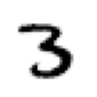

In [6]:
from fastai.vision.core import show_image

# Open a single image of the digit "3" and display it
# This is a 28x28 grayscale image
im3 = Image.open(path/'train'/'3'/'12.png')
show_image(im3);

Now we're going to take the top 3×3-pixel square of our image, and multiply each of those values by each item in our kernel. Then we'll add them up, like so:

In [7]:
# Convert PIL image to a tensor of pixel values (28x28 integers, 0-255)
# np.array() converts the PIL image to a numpy array first, then tensor() wraps it
im3_t = tensor(np.array(im3))

# Take the top-left 3x3 patch and multiply element-wise with the kernel
# Each pixel × corresponding kernel weight
im3_t[0:3,0:3] * top_edge

tensor([[-0., -0., -0.],
        [0., 0., 0.],
        [0., 0., 0.]])

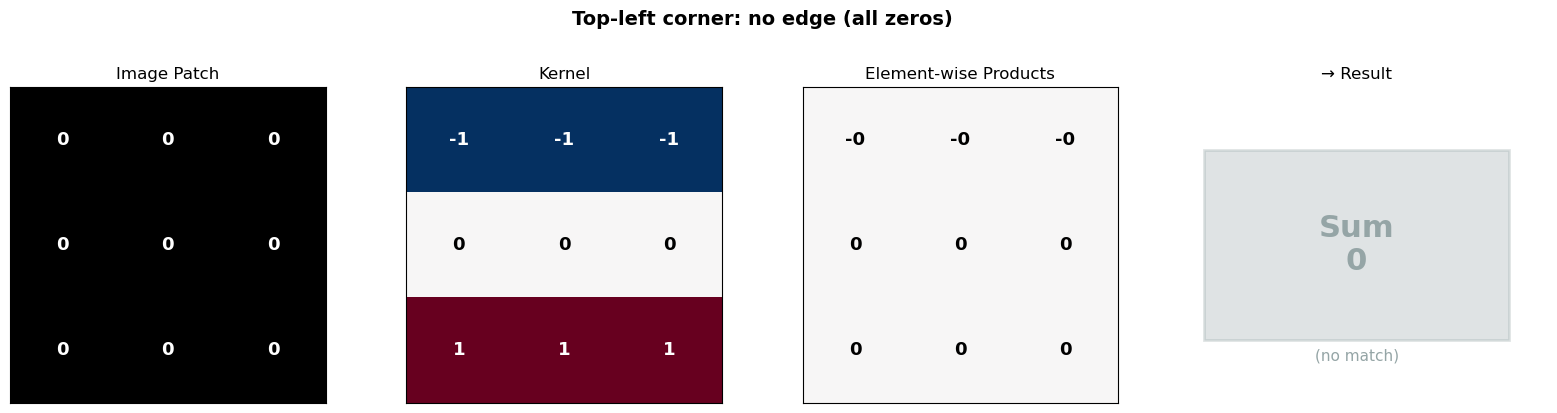

In [8]:
# Visualize: what happens when we convolve the top-left corner (all zeros)?
patch = im3_t[0:3, 0:3]
plot_conv_trace(patch, top_edge, title="Top-left corner: no edge (all zeros)")

The top-left corner is all zeros (white background) — so every multiplication is `0 × something = 0`. The sum is zero. No edge detected, which makes sense: there's nothing there.

This is the core operation of a convolution: **overlay the kernel on a patch, multiply each pair of numbers, sum the products.** The result is a single number that tells you how strongly that patch matches the pattern the kernel is looking for.

Now let's look at patches where there actually *is* an edge — the numbers will be much more interesting.

In [9]:
# Sum the element-wise products → one number = the convolution output for this position
# Near zero here because the top-left corner is all white (uniform → no edge)
(im3_t[0:3,0:3] * top_edge).sum()

tensor(0.)

Not very interesting so far—all the pixels in the top-left corner are white. But let's pick a couple of more interesting spots:

In [10]:
# Visualize the top-left corner of the image as a heatmap of pixel values
# Darker cells = higher pixel values (closer to the stroke of the digit)
df = pd.DataFrame(im3_t[:10,:20])
df.style.set_properties(**{'font-size':'6pt'}).background_gradient('Greys')

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,12,99,91,142,155,246,182,155,155,155,155,131,52,0,0,0,0
6,0,0,0,138,254,254,254,254,254,254,254,254,254,254,254,252,210,122,33,0
7,0,0,0,220,254,254,254,235,189,189,189,189,150,189,205,254,254,254,75,0
8,0,0,0,35,74,35,35,25,0,0,0,0,0,0,13,224,254,254,153,0
9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,90,254,254,247,53,0


<img alt="Top section of a digit" width="490" src="images/att_00059.png">

There's a top edge at cell 5,8. Let's repeat our calculation there:

In [11]:
# Apply kernel at row 4-7, col 6-9 — there's a top edge here (dark above, light below)
# Should return a large positive number
(im3_t[4:7,6:9] * top_edge).sum()

tensor(762.)

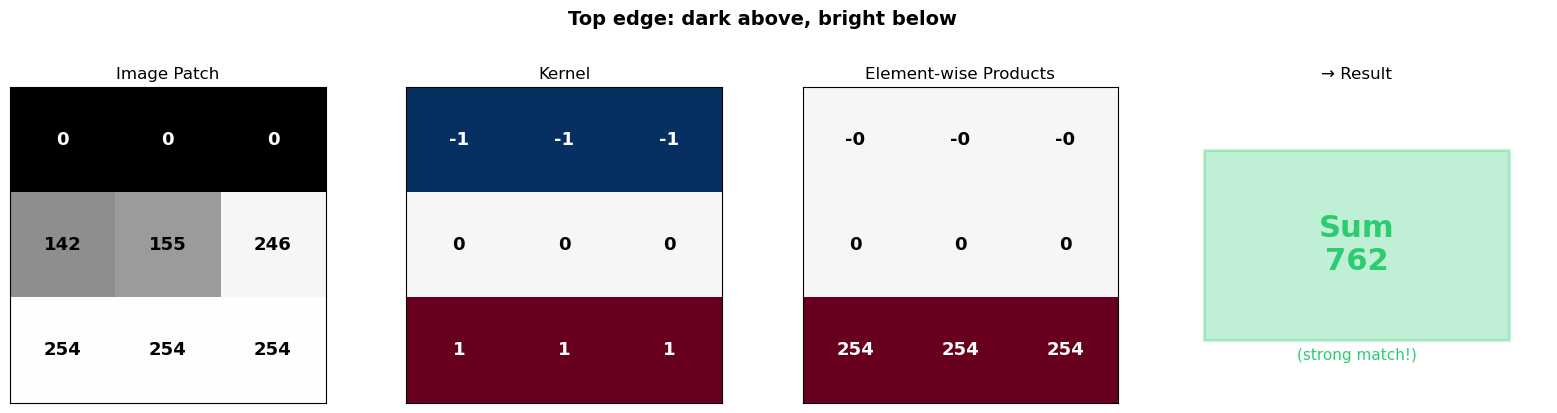

In [12]:
# Visualize: what happens at a REAL top edge (dark above, bright below)?
patch_edge = im3_t[4:7, 6:9]
plot_conv_trace(patch_edge, top_edge, title="Top edge: dark above, bright below")

Look at the products grid. The kernel's `-1` row (top) multiplied by dark pixels (≈0) produces near-zero. The kernel's `+1` row (bottom) multiplied by bright pixels (254) produces large positives. The middle row is always zero. The sum is strongly positive: "yes, there's a top edge here."

When the pattern is reversed (bright above, dark below), the `-1` row hits bright pixels and produces large *negatives*. The sum flips negative: "this is the opposite of a top edge."

There's a right edge at cell 8,18. What does that give us?:

In [13]:
# Apply at row 7-10, col 17-20 — this is a bottom edge (light above, dark below)
# Should return a negative number (opposite of what top_edge detects)
(im3_t[7:10,17:20] * top_edge).sum()

tensor(-29.)

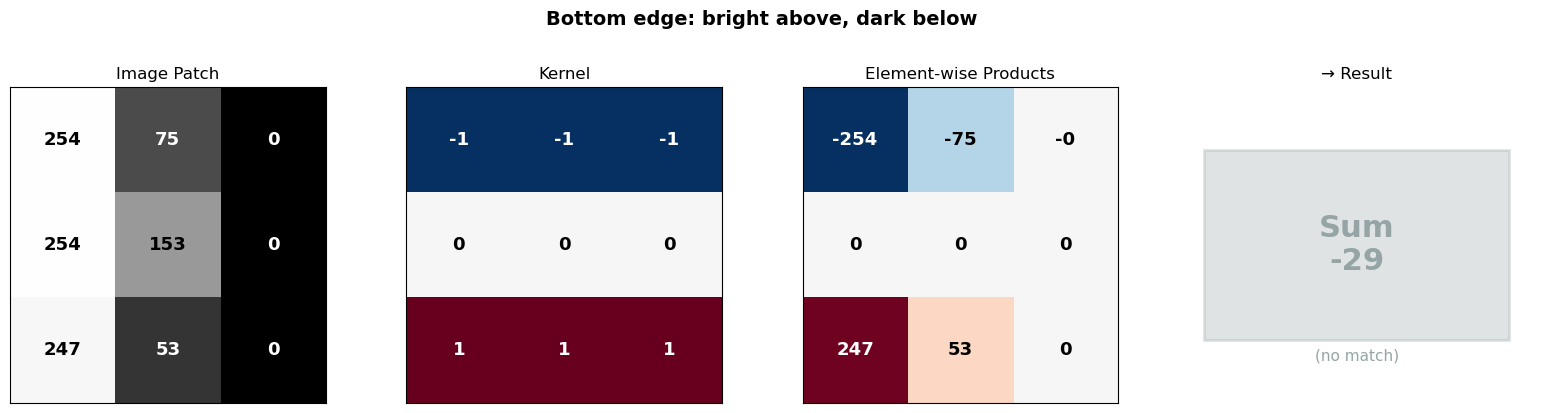

In [14]:
# Visualize: bottom edge — the opposite pattern
patch_bottom = im3_t[7:10, 17:20]
plot_conv_trace(patch_bottom, top_edge, title="Bottom edge: bright above, dark below")

As you can see, this little calculation is returning a high number where the 3×3-pixel square represents a top edge (i.e., where there are low values at the top of the square, and high values immediately underneath). That's because the `-1` values in our kernel have little impact in that case, but the `1` values have a lot.

Let's look a tiny bit at the math. The filter will take any window of size 3×3 in our images, and if we name the pixel values like this:

$$\begin{matrix} a1 & a2 & a3 \\ a4 & a5 & a6 \\ a7 & a8 & a9 \end{matrix}$$

it will return $-a1-a2-a3+a7+a8+a9$. If we are in a part of the image where $a1$, $a2$, and $a3$ add up to the same as $a7$, $a8$, and $a9$, then the terms will cancel each other out and we will get 0. However, if $a7$ is greater than $a1$, $a8$ is greater than $a2$, and $a9$ is greater than $a3$, we will get a bigger number as a result. So this filter detects horizontal edges—more precisely, edges where we go from bright parts of the image at the top to darker parts at the bottom.

Changing our filter to have the row of `1`s at the top and the `-1`s at the bottom would detect horizontal edges that go from dark to light. Putting the `1`s and `-1`s in columns versus rows would give us filters that detect vertical edges. Each set of weights will produce a different kind of outcome.

Let's create a function to do this for one location, and check it matches our result from before:

In [15]:
# Helper: apply a 3x3 kernel centered at (row, col) in the image
# Grabs the 3x3 patch around that position, element-wise multiplies with kernel, sums
def apply_kernel(row, col, kernel):
    return (im3_t[row-1:row+2,col-1:col+2] * kernel).sum()

In [16]:
# Test: same result as our manual calculation above
apply_kernel(5,7,top_edge)

tensor(762.)

But note that we can't apply it to the corner (e.g., location 0,0), since there isn't a complete 3×3 square there.

### Mapping a Convolution Kernel

We can map `apply_kernel()` across the coordinate grid. That is, we'll be taking our 3×3 kernel, and applying it to each 3×3 section of our image. For instance,  shows the positions a 3×3 kernel can be applied to in the first row of a 5×5 image.

<img src="images/chapter9_nopadconv.svg" id="nopad_conv" caption="Applying a kernel across a grid" alt="Applying a kernel across a grid" width="400">

To get a grid of coordinates we can use a *nested list comprehension*, like so:

In [17]:
# Nested list comprehension: generates a grid of (row, col) coordinates
# This is the pattern we'll use to apply the kernel at every valid position
[[(i,j) for j in range(1,5)] for i in range(1,5)]

[[(1, 1), (1, 2), (1, 3), (1, 4)],
 [(2, 1), (2, 2), (2, 3), (2, 4)],
 [(3, 1), (3, 2), (3, 3), (3, 4)],
 [(4, 1), (4, 2), (4, 3), (4, 4)]]

📝 **Note:** Nested List Comprehensions: Nested list comprehensions are used a lot in Python, so if you haven't seen them before, take a few minutes to make sure you understand what's happening here, and experiment with writing your own nested list comprehensions.

Here's the result of applying our kernel over a coordinate grid:

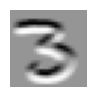

In [18]:
from fastai.vision.core import show_image

# Apply the top-edge kernel at every valid position in the 28x28 image
# range(1,27) because we can't center a 3x3 kernel on the border pixels
rng = range(1,27)
top_edge3 = tensor([[apply_kernel(i,j,top_edge) for j in rng] for i in rng])

# Bright pixels = strong top edges detected, dark = bottom edges
show_image(top_edge3);

Looking good! Our top edges are black, and bottom edges are white (since they are the *opposite* of top edges). Now that our image contains negative numbers too, `matplotlib` has automatically changed our colors so that white is the smallest number in the image, black the highest, and zeros appear as gray.

We can try the same thing for left edges:

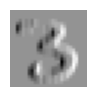

In [19]:
from fastai.vision.core import show_image

# Left-edge kernel: detects vertical edges (dark on left, light on right)
# -1s in left column, 1s in middle column, 0s on right
left_edge = tensor([[-1,1,0],
                    [-1,1,0],
                    [-1,1,0]]).float()

# Apply across the whole image, same as before
left_edge3 = tensor([[apply_kernel(i,j,left_edge) for j in rng] for i in rng])

show_image(left_edge3);

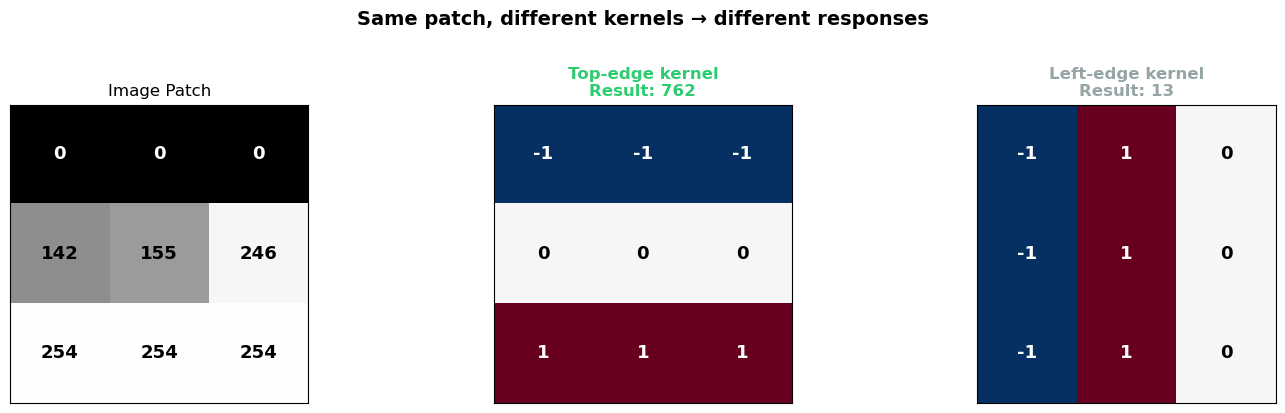

In [20]:
# Same patch tested with two different kernels — which edge does it detect?
patch_compare = im3_t[4:7, 6:9]
plot_kernel_comparison(
    patch_compare,
    [top_edge, left_edge],
    ["Top-edge kernel", "Left-edge kernel"],
    title="Same patch, different kernels → different responses"
)

The top-edge kernel fires strongly (762) because there's a clear horizontal edge. The left-edge kernel barely responds (13) because there's no vertical edge at this location. Different kernel = different pattern detector, same underlying operation.

Now we've been doing this at individual positions. To build a complete "edge map," we slide the kernel across *every* valid position and collect the results into a new image. Each pixel in the output tells you "how strongly did the kernel's pattern match here?"

As we mentioned before, a **convolution** is the operation of applying such a kernel over a grid in this way — the sliding, multiplying, and summing. The **feature map** (also called activation map) is the result: the new matrix of all those output values collected together. So convolution = the process, feature map = the output. One kernel produces one feature map. 16 kernels produce 16 feature maps — each one a "heat map" of where a different pattern was detected.

In the paper ["A Guide to Convolution Arithmetic for Deep Learning"](https://arxiv.org/abs/1603.07285) there are many great diagrams showing how image kernels can be applied. Here's an example from the paper showing (at the bottom) a light blue 4×4 image, with a dark blue 3×3 kernel being applied, creating a 2×2 green output feature map at the top.

<img alt="Result of applying a 3×3 kernel to a 4×4 image" width="782" caption="Result of applying a 3×3 kernel to a 4×4 image (courtesy of Vincent Dumoulin and Francesco Visin)" id="three_ex_four_conv" src="images/att_00028.png">

Look at the shape of the result. If the original image has a height of `h` and a width of `w`, how many 3×3 windows can we find? As you can see from the example, there are `h-2` by `w-2` windows, so the image we get has a result as a height of `h-2` and a width of `w-2`.

We won't implement this convolution function from scratch, but use PyTorch's implementation instead (it is way faster than anything we could do in Python).

### Convolutions in PyTorch

Convolution is such an important and widely used operation that PyTorch has it built in. It's called `F.conv2d` (recall that `F` is a fastai import from `torch.nn.functional`, as recommended by PyTorch). The PyTorch docs tell us that it includes these parameters:

- input:: input tensor of shape `(minibatch, in_channels, iH, iW)`
- weight:: filters of shape `(out_channels, in_channels, kH, kW)`

Here `iH,iW` is the height and width of the image (i.e., `28,28`), and `kH,kW` is the height and width of our kernel (`3,3`). But apparently PyTorch is expecting rank-4 tensors for both these arguments, whereas currently we only have rank-2 tensors (i.e., matrices, or arrays with two axes).

The reason for these extra axes is that PyTorch has a few tricks up its sleeve. The first trick is that PyTorch can apply a convolution to multiple images at the same time. That means we can call it on every item in a batch at once!

The second trick is that PyTorch can apply multiple kernels at the same time. So let's create the diagonal-edge kernels too, and then stack all four of our edge kernels into a single tensor:

In [21]:
# Two diagonal edge kernels
diag1_edge = tensor([[ 0,-1, 1],
                     [-1, 1, 0],
                     [ 1, 0, 0]]).float()
diag2_edge = tensor([[ 1,-1, 0],
                     [ 0, 1,-1],
                     [ 0, 0, 1]]).float()

# Stack all 4 kernels into one tensor: shape (4, 3, 3)
# 4 kernels, each 3x3 — we'll apply all of them at once using F.conv2d
edge_kernels = torch.stack([left_edge, top_edge, diag1_edge, diag2_edge])
edge_kernels.shape

torch.Size([4, 3, 3])

To test this, we'll need a `DataLoader` and a sample mini-batch. Let's use the data block API:

In [22]:
from fastai.vision.core import PILImageBW
from fastai.vision.all import ImageBlock
from fastai.data.block import DataBlock, CategoryBlock
from fastai.data.transforms import get_image_files, GrandparentSplitter, parent_label
from fastcore.basics import first

# Create a DataBlock for MNIST 3s vs 7s
# ImageBlock(cls=PILImageBW) = grayscale images
# CategoryBlock = the labels (3 or 7)
# GrandparentSplitter = split train/valid based on grandparent folder name
# parent_label = use the parent folder name as the label
mnist = DataBlock((ImageBlock(cls=PILImageBW), CategoryBlock), 
                  get_items=get_image_files, 
                  splitter=GrandparentSplitter(),
                  get_y=parent_label)

dls = mnist.dataloaders(path)

# Grab one batch: xb = images, yb = labels
xb,yb = first(dls.valid)
xb.shape  # (batch_size, channels, height, width) = (64, 1, 28, 28)

torch.Size([64, 1, 28, 28])

By default, fastai puts data on the GPU when using data blocks. Let's move it to the CPU for our examples:

In [23]:
from fastai.torch_core import to_cpu

# Move batch to CPU for manual convolution (fastai puts data on GPU by default)
xb,yb = to_cpu(xb),to_cpu(yb)

One batch contains 64 images, each of 1 channel, with 28×28 pixels. `F.conv2d` can handle multichannel (i.e., color) images too. A *channel* is a single basic color in an image—for regular full-color images there are three channels, red, green, and blue. PyTorch represents an image as a rank-3 tensor, with dimensions `[channels, rows, columns]`.

We'll see how to handle more than one channel later in this chapter. Kernels passed to `F.conv2d` need to be rank-4 tensors: `[channels_in, features_out, rows, columns]`. `edge_kernels` is currently missing one of these. We need to tell PyTorch that the number of input channels in the kernel is one, which we can do by inserting an axis of size one (this is known as a *unit axis*) in the first location, where the PyTorch docs show `in_channels` is expected. To insert a unit axis into a tensor, we use the `unsqueeze` method:

In [24]:
# F.conv2d expects kernels shaped (out_channels, in_channels, H, W)
# Our kernels are (4, 3, 3) — missing the in_channels dimension
# unsqueeze(1) adds it: (4, 3, 3) → (4, 1, 3, 3) — 4 filters, 1 input channel each
edge_kernels.shape, edge_kernels.unsqueeze(1).shape

(torch.Size([4, 3, 3]), torch.Size([4, 1, 3, 3]))

This is now the correct shape for `edge_kernels`. Let's pass this all to `conv2d`:

In [25]:
# Reshape kernels to have the input channel dimension
edge_kernels = edge_kernels.unsqueeze(1)  # (4, 1, 3, 3)

In [26]:
# Apply all 4 edge kernels to all 64 images in one shot
# Input: (64, 1, 28, 28) — 64 grayscale images
# Kernels: (4, 1, 3, 3) — 4 filters
# Output: (64, 4, 26, 26) — 64 images × 4 feature maps × 26x26 (shrunk by 2 due to no padding)
batch_features = F.conv2d(xb, edge_kernels)
batch_features.shape

torch.Size([64, 4, 26, 26])

The output shape shows we gave 64 images in the mini-batch, 4 kernels, and 26×26 edge maps (we started with 28×28 images, but lost one pixel from each side as discussed earlier). We can see we get the same results as when we did this manually:

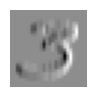

In [27]:
from fastai.vision.core import show_image

# Show the first feature map of the first image (left-edge detection)
show_image(batch_features[0,0]);

The most important trick that PyTorch has up its sleeve is that it can use the GPU to do all this work in parallel—that is, applying multiple kernels, to multiple images, across multiple channels. Doing lots of work in parallel is critical to getting GPUs to work efficiently; if we did each of these operations one at a time, we'd often run hundreds of times slower (and if we used our manual convolution loop from the previous section, we'd be millions of times slower!). Therefore, to become a strong deep learning practitioner, one skill to practice is giving your GPU plenty of work to do at a time.

It would be nice to not lose those two pixels on each axis. The way we do that is to add *padding*, which is simply additional pixels added around the outside of our image. Most commonly, pixels of zeros are added. 

### Strides and Padding

With appropriate padding, we can ensure that the output activation map is the same size as the original image, which can make things a lot simpler when we construct our architectures.  shows how adding padding allows us to apply the kernels in the image corners.

<img src="images/chapter9_padconv.svg" id="pad_conv" caption="A convolution with padding" alt="A convolution with padding" width="600">

With a 5×5 input, 4×4 kernel, and 2 pixels of padding, we end up with a 6×6 activation map, as we can see in .

<img alt="A 4×4 kernel with 5×5 input and 2 pixels of padding" width="783" caption="A 4×4 kernel with 5×5 input and 2 pixels of padding (courtesy of Vincent Dumoulin and Francesco Visin)" id="four_by_five_conv" src="images/att_00029.png">

If we add a kernel of size `ks` by `ks` (with `ks` an odd number), the necessary padding on each side to keep the same shape is `ks//2`. An even number for `ks` would require a different amount of padding on the top/bottom and left/right, but in practice we almost never use an even filter size.

So far, when we have applied the kernel to the grid, we have moved it one pixel over at a time. But we can jump further; for instance, we could move over two pixels after each kernel application, as in . This is known as a *stride-2* convolution. The most common kernel size in practice is 3×3, and the most common padding is 1. As you'll see, stride-2 convolutions are useful for decreasing the size of our outputs, and stride-1 convolutions are useful for adding layers without changing the output size.

<img alt="A 3×3 kernel with 5×5 input, stride-2 convolution, and 1 pixel of padding" width="774" caption="A 3×3 kernel with 5×5 input, stride-2 convolution, and 1 pixel of padding (courtesy of Vincent Dumoulin and Francesco Visin)" id="three_by_five_conv" src="images/att_00030.png">

In an image of size `h` by `w`, using a padding of 1 and a stride of 2 will give us a result of size `(h+1)//2` by `(w+1)//2`. The general formula for each dimension is `(n + 2*pad - ks)//stride + 1`, where `pad` is the padding, `ks`, the size of our kernel, and `stride` is the stride.

Let's now take a look at how the pixel values of the result of our convolutions are computed.

### Understanding the Convolution Equations

To explain the math behind convolutions, fast.ai student Matt Kleinsmith came up with the very clever idea of showing [CNNs from different viewpoints](https://medium.com/impactai/cnns-from-different-viewpoints-fab7f52d159c). In fact, it's so clever, and so helpful, we're going to show it here too!

Here's our 3×3 pixel image, with each pixel labeled with a letter:

<img alt="The image" width="75" src="images/att_00032.png">

And here's our kernel, with each weight labeled with a Greek letter:

<img alt="The kernel" width="55" src="images/att_00033.png">

Since the filter fits in the image four times, we have four results:

<img alt="The activations" width="52" src="images/att_00034.png">

 shows how we applied the kernel to each section of the image to yield each result.

<img alt="Applying the kernel" width="366" caption="Applying the kernel" id="apply_kernel" src="images/att_00035.png">

The equation view is in .

<img alt="The equation" width="436" caption="The equation" id="eq_view" src="images/att_00036.png">

Notice that the bias term, *b*, is the same for each section of the image. You can consider the bias as part of the filter, just like the weights (α, β, γ, δ) are part of the filter.

Here's an interesting insight—a convolution can be represented as a special kind of matrix multiplication, as illustrated in . The weight matrix is just like the ones from traditional neural networks. However, this weight matrix has two special properties:

1. The zeros shown in gray are untrainable. This means that they’ll stay zero throughout the optimization process.
1. Some of the weights are equal, and while they are trainable (i.e., changeable), they must remain equal. These are called *shared weights*.

The zeros correspond to the pixels that the filter can't touch. Each row of the weight matrix corresponds to one application of the filter.

<img alt="Convolution as matrix multiplication" width="683" caption="Convolution as matrix multiplication" id="conv_matmul" src="images/att_00038.png">

Now that we understand what a convolution is, let's use them to build a neural net.

## Our First Convolutional Neural Network

There is no reason to believe that some particular edge filters are the most useful kernels for image recognition. Furthermore, we've seen that in later layers convolutional kernels become complex transformations of features from lower levels, but we don't have a good idea of how to manually construct these.

Instead, it would be best to learn the values of the kernels. We already know how to do this—SGD! In effect, the model will learn the features that are useful for classification.

When we use convolutions instead of (or in addition to) regular linear layers we create a *convolutional neural network* (CNN).

### Creating the CNN

Let's go back to the  basic neural network we had in . It was defined like this:

In [28]:
# For reference: the simple MLP from earlier chapters
# Flattens 28x28 image to 784 numbers, maps through one hidden layer
# This is what we're replacing with convolutions
simple_net = nn.Sequential(
    nn.Linear(28*28,30),  # 784 inputs → 30 hidden
    nn.ReLU(),
    nn.Linear(30,1)       # 30 → 1 output
)

We can view a model's definition:

In [29]:
# Print the model structure
simple_net

Sequential(
  (0): Linear(in_features=784, out_features=30, bias=True)
  (1): ReLU()
  (2): Linear(in_features=30, out_features=1, bias=True)
)

We now want to create a similar architecture to this linear model, but using convolutional layers instead of linear. `nn.Conv2d` is the module equivalent of `F.conv2d`. It's more convenient than `F.conv2d` when creating an architecture, because it creates the weight matrix for us automatically when we instantiate it.

Here's a possible architecture:

In [30]:
from fastai.layers import sequential

# Naive attempt: replace linear layers with conv layers
# Problem: output is still (batch, 1, 28, 28) — a full spatial grid, not a single prediction
broken_cnn = sequential(
    nn.Conv2d(1, 30, kernel_size=3, padding=1),   # 1 channel in → 30 channels out, same spatial size
    nn.ReLU(),
    nn.Conv2d(30, 1, kernel_size=3, padding=1)    # 30 → 1 channel, still 28x28
)

One thing to note here is that we didn't need to specify 28×28 as the input size. That's because a linear layer needs a weight in the weight matrix for every pixel, so it needs to know how many pixels there are, but a convolution is applied over each pixel automatically. The weights only depend on the number of input and output channels and the kernel size, as we saw in the previous section.

Think about what the output shape is going to be, then let's try it and see:

In [31]:
# Shape: (64, 1, 28, 28) — still a full image per sample, not a single class prediction!
# We need to shrink the spatial dimensions down to 1x1
broken_cnn(xb).shape

torch.Size([64, 1, 28, 28])

This is not something we can use to do classification, since we need a single output activation per image, not a 28×28 map of activations. One way to deal with this is to use enough stride-2 convolutions such that the final layer is size 1. That is, after one stride-2 convolution the size will be 14×14, after two it will be 7×7, then 4×4, 2×2, and finally size 1.

Let's try that now. First, we'll define a function with the basic parameters we'll use in each convolution:

In [32]:
# Helper: create a conv layer with stride=2 (halves spatial dimensions each time)
# padding = kernel_size // 2 keeps the halving clean (ks=3 → padding=1, ks=5 → padding=2)
def conv(in_channels, out_channels, kernel_size=3, activation=True):
    layer = nn.Conv2d(
        in_channels=in_channels,
        out_channels=out_channels,
        kernel_size=kernel_size,
        stride=2,
        padding=kernel_size // 2
    )
    if activation:
        layer = nn.Sequential(layer, nn.ReLU())
    return layer

**Why we wrap `conv` in a helper:** Every layer uses the same stride, padding formula, and optional ReLU. Putting that in a function means you only change `ni` and `nf` per layer — less room for mistakes, and it's immediately obvious what's actually changing between layers.

**Why double the channels when spatial size halves?** Stride 2 halves both width and height, so a 14x14 feature map becomes 7x7 — that's ÷4 total values per feature map. If we kept the same number of channels, the layer would carry way less information. Doubling the channels (×2) partially compensates, so capacity stays roughly balanced across layers. This isn't a strict rule, just a convention that works well.

**Terminology note: "channels" vs "features."** In CNNs, both words mean the same thing — the number of feature maps at a given layer. "This layer has 32 features" = "this layer has 32 channels" = 32 feature maps. This is different from tabular ML where "features" means columns. The word is just overloaded depending on context.

Here is how we can build a simple CNN:

In [33]:
from fastai.layers import sequential, Flatten

# Helper: create a conv layer with stride=2 (halves spatial dimensions each time)
# padding = kernel_size // 2 keeps the halving clean (ks=3 → padding=1, ks=5 → padding=2)
def conv(in_channels, out_channels, kernel_size=3, activation=True):
    layer = nn.Conv2d(
        in_channels=in_channels,
        out_channels=out_channels,
        kernel_size=kernel_size,
        stride=2,
        padding=kernel_size // 2
    )
    if activation:
        layer = nn.Sequential(layer, nn.ReLU())
    return layer

# Build the CNN: each conv layer halves spatial dimensions (stride=2) and grows channels
# Spatial:  28x28 → 14x14 → 7x7 → 4x4 → 2x2 → 1x1
# Channels:   1  →   4   →  8  → 16  → 32  →  2 (one per class)
simple_cnn = sequential(
    conv(in_channels=1,  out_channels=4),               # 28x28 → 14x14
    conv(in_channels=4,  out_channels=8),               # 14x14 → 7x7
    conv(in_channels=8,  out_channels=16),              # 7x7   → 4x4
    conv(in_channels=16, out_channels=32),              # 4x4   → 2x2
    conv(in_channels=32, out_channels=2, activation=False),  # 2x2 → 1x1, no ReLU (raw logits for cross-entropy)
    Flatten(),                                          # (batch, 2, 1, 1) → (batch, 2)
)

📖 **Jargon:** I like to add comments like the ones here after each convolution to show how large the activation map will be after each layer. These comments assume that the input size is 28*28

Now the network outputs two activations, which map to the two possible levels in our labels:

In [34]:
# Verify: output is (64, 2) — 64 images, 2 class scores each
simple_cnn(xb).shape

torch.Size([64, 2])

We can now create our `Learner`:

In [35]:
from fastai.learner import Learner
from fastai.metrics import accuracy

# Create a Learner: wraps model + data + loss + metrics into one training object
# cross_entropy: softmax + negative log likelihood (standard for classification)
learn = Learner(dls, simple_cnn, loss_func=F.cross_entropy, metrics=accuracy)

To see exactly what's going on in the model, we can use `summary`:

In [36]:
# Summary shows input/output shapes and parameter counts at each layer
learn.summary()

Sequential (Input shape: 64 x 1 x 28 x 28)
Layer (type)         Output Shape         Param #    Trainable 
                     64 x 4 x 14 x 14    
Conv2d                                    40         True      
ReLU                                                           
____________________________________________________________________________
                     64 x 8 x 7 x 7      
Conv2d                                    296        True      
ReLU                                                           
____________________________________________________________________________
                     64 x 16 x 4 x 4     
Conv2d                                    1168       True      
ReLU                                                           
____________________________________________________________________________
                     64 x 32 x 2 x 2     
Conv2d                                    4640       True      
ReLU                                          

Note that the output of the final `Conv2d` layer is `64x2x1x1`. We need to remove those extra `1x1` axes; that's what `Flatten` does. It's basically the same as PyTorch's `squeeze` method, but as a module.

Let's see if this trains! Since this is a deeper network than we've built from scratch before, we'll use a lower learning rate and more epochs:

In [37]:
# Train for 2 epochs using 1cycle learning rate schedule
# 1cycle: starts low, ramps up to max lr (0.01), then decays back down
learn.fit_one_cycle(10, 0.01)

epoch,train_loss,valid_loss,accuracy,time
0,0.153016,0.080614,0.975957,00:00
1,0.044790,0.050258,0.982336,00:00
2,0.027452,0.033082,0.990677,00:00
3,0.019932,0.024735,0.992149,00:00
4,0.016525,0.015419,0.996565,00:00
5,0.009133,0.017526,0.996565,00:00
6,0.007143,0.017914,0.997056,00:00
7,0.002150,0.020756,0.996565,00:00
8,0.000555,0.022182,0.996565,00:00
9,0.000218,0.022706,0.996565,00:00


Success! It's getting closer to the `resnet18` result we had, although it's not quite there yet, and it's taking more epochs, and we're needing to use a lower learning rate. We still have a few more tricks to learn, but we're getting closer and closer to being able to create a modern CNN from scratch.

### Understanding Convolution Arithmetic

We can see from the summary that we have an input of size `64x1x28x28`. The axes are `batch,channel,height,width`. This is often represented as `NCHW` (where `N` refers to batch size). Tensorflow, on the other hand, uses `NHWC` axis order. The first layer is:

In [38]:
# Grab the first block of the model (Conv2d + ReLU)
m = learn.model[0]
m

Sequential(
  (0): Conv2d(1, 4, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (1): ReLU()
)

So we have 1 input channel, 4 output channels, and a 3×3 kernel. Let's check the weights of the first convolution:

In [39]:
# Weight shape: (out_channels, in_channels, kernel_h, kernel_w) = (4, 1, 3, 3)
# 4 filters, each looking at 1 input channel, each 3x3
# Total weight params: 4 × 1 × 3 × 3 = 36
m[0].weight.shape

torch.Size([4, 1, 3, 3])

The summary shows we have 40 parameters, and `4*1*3*3` is 36. What are the other four parameters? Let's see what the bias contains:

In [40]:
# Bias shape: (4,) — one bias per output channel
# 36 weights + 4 biases = 40 total parameters (matches the summary)
m[0].bias.shape

torch.Size([4])

We can now use this information to clarify our statement in the previous section: "When we use a stride-2 convolution, we often increase the number of features because we're decreasing the number of activations in the activation map by a factor of 4; we don't want to decrease the capacity of a layer by too much at a time."

There is one bias for each channel. (Sometimes channels are called *features* or *filters* when they are not input channels.) The output shape is `64x4x14x14`, and this will therefore become the input shape to the next layer. The next layer, according to `summary`, has 296 parameters. Let's ignore the batch axis to keep things simple. So for each of `14*14=196` locations we are multiplying `296-8=288` weights (ignoring the bias for simplicity), so that's `196*288=56_448` multiplications at this layer. The next layer will have `7*7*(1168-16)=56_448` multiplications.

What happened here is that our stride-2 convolution halved the *grid size* from `14x14` to `7x7`, and we doubled the *number of filters* from 8 to 16, resulting in no overall change in the amount of computation. If we left the number of channels the same in each stride-2 layer, the amount of computation being done in the net would get less and less as it gets deeper. But we know that the deeper layers have to compute semantically rich features (such as eyes or fur), so we wouldn't expect that doing *less* computation would make sense.

Another way to think of this is based on receptive fields.

### Receptive Fields

The *receptive field* is the area of an image that is involved in the calculation of a layer. On the [book's website](https://book.fast.ai/), you'll find an Excel spreadsheet called *conv-example.xlsx* that shows the calculation of two stride-2 convolutional layers using an MNIST digit. Each layer has a single kernel.  shows what we see if we click on one of the cells in the *conv2* section, which shows the output of the second convolutional layer, and click *trace precedents*.

<img alt="Immediate precedents of conv2 layer" width="308" caption="Immediate precedents of Conv2 layer" id="preced1" src="images/att_00068.png">

Here, the cell with the green border is the cell we clicked on, and the blue highlighted cells are its *precedents*—that is, the cells used to calculate its value. These cells are the corresponding 3×3 area of cells from the input layer (on the left), and the cells from the filter (on the right). Let's now click *trace precedents* again, to see what cells are used to calculate these inputs.  shows what happens.

<img alt="Secondary precedents of conv2 layer" width="601" caption="Secondary precedents of Conv2 layer" id="preced2" src="images/att_00069.png">

In this example, we have just two convolutional layers, each of stride 2, so this is now tracing right back to the input image. We can see that a 7×7 area of cells in the input layer is used to calculate the single green cell in the Conv2 layer. This 7×7 area is the *receptive field* in the input of the green activation in Conv2. We can also see that a second filter kernel is needed now, since we have two layers.

As you see from this example, the deeper we are in the network (specifically, the more stride-2 convs we have before a layer), the larger the receptive field for an activation in that layer. A large receptive field means that a large amount of the input image is used to calculate each activation in that layer is. We now know that in the deeper layers of the network we have semantically rich features, corresponding to larger receptive fields. Therefore, we'd expect that we'd need more weights for each of our features to handle this increasing complexity. This is another way of saying the same thing we mentioned in the previous section: when we introduce a stride-2 conv in our network, we should also increase the number of channels.

## Color Images

A colour picture is a rank-3 tensor:

In [41]:
from fastai.vision.core import image2tensor
from fastbook import image_bear

# Load a sample color image (a bear) and convert to tensor
# Shape: (3, H, W) — 3 channels (R, G, B), height, width
im = image2tensor(Image.open(image_bear()))
im.shape

torch.Size([3, 1000, 846])

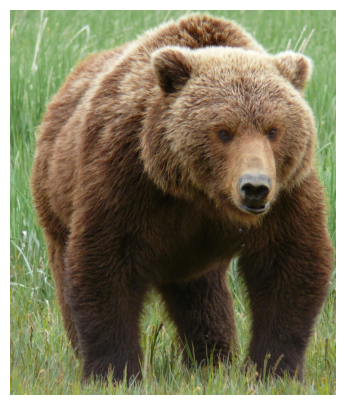

In [42]:
from fastai.vision.core import show_image

# Display the full-color bear image
show_image(im);

The first axis contains the channels, red, green, and blue:

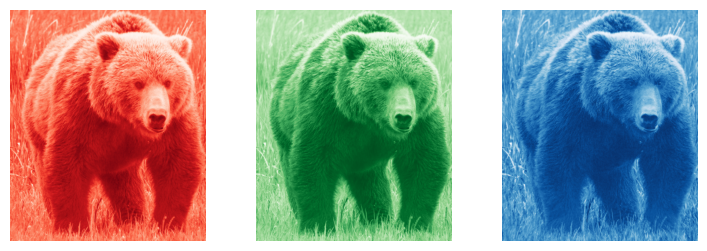

In [43]:
from fastai.vision.core import show_image, subplots

# Split the image into its 3 color channels and display each separately
# 255-bear inverts the values so the bear shows up on a white background
_,axs = subplots(1,3)
for bear,ax,color in zip(im,axs,('Reds','Greens','Blues')):
    show_image(255-bear, ax=ax, cmap=color)

We saw what the convolution operation was for one filter on one channel of the image (our examples were done on a square). A convolutional layer will take an image with a certain number of channels (three for the first layer for regular RGB color images) and output an image with a different number of channels. Like our hidden size that represented the numbers of neurons in a linear layer, we can decide to have as many filters as we want, and each of them will be able to specialize, some to detect horizontal edges, others to detect vertical edges and so forth, to give something like we studied in .

In one sliding window, we have a certain number of channels and we need as many filters (we don't use the same kernel for all the channels). So our kernel doesn't have a size of 3 by 3, but `ch_in` (for channels in) is 3 by 3. On each channel, we multiply the elements of our window by the elements of the coresponding filter, then sum the results (as we saw before) and sum over all the filters. In the example given in , the result of our conv layer on that window is red + green + blue.

<img src="images/chapter9_rgbconv.svg" id="rgbconv" caption="Convolution over an RGB image" alt="Convolution over an RGB image" width="550">

So, in order to apply a convolution to a color picture we require a kernel tensor with a size that matches the first axis. At each location, the corresponding parts of the kernel and the image patch are multiplied together.

These are then all added together, to produce a single number, for each grid location, for each output feature, as shown in .

Note that the kernel itself is a rank-3 tensor (3×3×3 for an RGB image — one 3×3 slice per color channel, each with its own independently learned weights). But the feature map it produces is a flat 2D grid. The third dimension gets collapsed by summing: 9 products from the red slice + 9 from green + 9 from blue = 27 multiplications, all summed into one number per position.

<img src="images/chapter9_rgb_conv_stack.svg" id="rgbconv2" caption="Adding the RGB filters" alt="Adding the RGB filters" width="500">

Then we have `ch_out` filters like this, so in the end, the result of our convolutional layer will be a batch of images with `ch_out` channels and a height and width given by the formula outlined earlier. This give us `ch_out` tensors of size `ch_in x ks x ks` that we represent in one big tensor of four dimensions. In PyTorch, the order of the dimensions for those weights is `ch_out x ch_in x ks x ks`.

Additionally, we may want to have a bias for each filter. In the preceding example, the final result for our convolutional layer would be $y_{R} + y_{G} + y_{B} + b$ in that case. Like in a linear layer, there are as many bias as we have kernels, so the biases is a vector of size `ch_out`.

There are no special mechanisms required when setting up a CNN for training with color images. Just make sure your first layer has three inputs.

There are lots of ways of processing color images. For instance, you can change them to black and white, change from RGB to HSV (hue, saturation, and value) color space, and so forth. In general, it turns out experimentally that changing the encoding of colors won't make any difference to your model results, as long as you don't lose information in the transformation. So, transforming to black and white is a bad idea, since it removes the color information entirely (and this can be critical; for instance, a pet breed may have a distinctive color); but converting to HSV generally won't make any difference.

Now you know what those pictures in  of "what a neural net learns" from the [Zeiler and Fergus paper](https://arxiv.org/abs/1311.2901) mean! This is their picture of some of the layer 1 weights which we showed:

<img alt="Layer 1 kernels found by Zeiler and Fergus" width="120" src="images/att_00031.png">

This is taking the three slices of the convolutional kernel, for each output feature, and displaying them as images. We can see that even though the creators of the neural net never explicitly created kernels to find edges, for instance, the neural net automatically discovered these features using SGD.

Now let's see how we can train these CNNs, and show you all the techniques fastai uses under the hood for efficient training.

## Improving Training Stability

Since we are so good at recognizing 3s from 7s, let's move on to something harder—recognizing all 10 digits. That means we'll need to use `MNIST` instead of `MNIST_SAMPLE`:

In [44]:
from fastai.data.transforms import untar_data, URLs

# Download full MNIST (all 10 digits, not just 3s vs 7s) — harder problem
path = untar_data(URLs.MNIST)

In [45]:
# Set base path for shorter display
Path.BASE_PATH = path

In [46]:
# List contents: should have 'training' and 'testing' folders
path.ls()

(#2) [Path('training'),Path('testing')]

The data is in two folders named *training* and *testing*, so we have to tell `GrandparentSplitter` about that (it defaults to `train` and `valid`). We did do that in the `get_dls` function, which we create to make it easy to change our batch size later:

In [47]:
from fastai.vision.core import PILImageBW
from fastai.vision.all import ImageBlock
from fastai.data.block import DataBlock, CategoryBlock
from fastai.data.transforms import get_image_files, GrandparentSplitter, parent_label, Normalize

# DataBlock for full MNIST (10 digits)
# GrandparentSplitter('training','testing') splits by folder name
# Normalize() standardizes pixel values (zero mean, unit variance)
def get_dls(bs=64):
    return DataBlock(
        blocks=(ImageBlock(cls=PILImageBW), CategoryBlock), 
        get_items=get_image_files, 
        splitter=GrandparentSplitter('training','testing'),
        get_y=parent_label,
        batch_tfms=Normalize()
    ).dataloaders(path, bs=bs)

dls = get_dls()

Remember, it's always a good idea to look at your data before you use it:

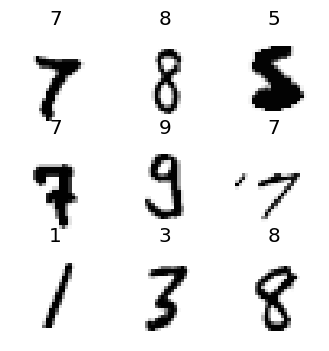

In [48]:
# Sanity check: visualize a batch to make sure data looks right
dls.show_batch(max_n=9, figsize=(4,4))

Now that we have our data ready, we can train a simple model on it.

### A Simple Baseline

Earlier in this chapter, we built a model based on a `conv` function like this:

In [49]:
# Same conv helper as before: stride-2 convolution + optional ReLU
def conv(in_channels, out_channels, kernel_size=3, activation=True):
    layer = nn.Conv2d(
        in_channels=in_channels,
        out_channels=out_channels,
        kernel_size=kernel_size,
        stride=2,
        padding=kernel_size // 2
    )
    if activation:
        layer = nn.Sequential(layer, nn.ReLU())
    return layer

We're switching from 2-class (3 vs 7) to 10-class (all digits), so we need more filters throughout the network. We double the first layer from 4 to 8 filters, which doubles every layer after it.

But there's a compression problem. A 3×3 kernel reads 9 input values per position. With 4 output filters, that's 9→4 — real compression, so the network must learn useful patterns. With 8 output filters, it's 9→8 — barely any compression. The network can just pass information through without learning much. Neural networks only create useful features when they're forced to squeeze many inputs into fewer outputs.

The fix: use a 5×5 kernel in the first layer. Now it's 25 input values → 8 outputs (25:8) — enough compression to force the network to learn meaningful features. Later layers stick with 3×3 because their input-to-output ratios are already fine (8→16, 16→32, etc.).

In [50]:
from fastai.layers import sequential, Flatten

# 10-class CNN: more channels than the 2-class version, 10 output channels (one per digit)
# First layer uses kernel_size=5 for a larger receptive field from the start
def simple_cnn():
    return sequential(
        conv(in_channels=1,  out_channels=8,  kernel_size=5),      # 28x28 → 14x14
        conv(in_channels=8,  out_channels=16),                     # 14x14 → 7x7
        conv(in_channels=16, out_channels=32),                     # 7x7   → 4x4
        conv(in_channels=32, out_channels=64),                     # 4x4   → 2x2
        conv(in_channels=64, out_channels=10, activation=False),   # 2x2   → 1x1, 10 classes
        Flatten(),
    )

Our CNN works for 3s vs 7s, but it will struggle with all 10 digits. To understand why, we'll use `ActivationStats` — a tool that records what's happening inside the network during training. Remember that activations are the output values of each layer (after the layer does its convolution + ReLU). `ActivationStats` tracks the mean, standard deviation, and distribution of these values at every layer, so we can see whether information is actually flowing through the network or dying off.

Let's train at a learning rate of 0.06 and see what happens:

In [51]:
from fastai.learner import Learner
from fastai.metrics import accuracy
from fastai.callback.hook import ActivationStats

# Training helper with ActivationStats callback to record layer statistics
# with_hist=True records full activation histograms (not just mean/std)
def fit(epochs=1):
    learn = Learner(dls, simple_cnn(), loss_func=F.cross_entropy,
                    metrics=accuracy, cbs=ActivationStats(with_hist=True))
    learn.fit(epochs, 0.06)
    return learn

In [52]:
# Train 1 epoch at lr=0.06 — this will train poorly, and we'll diagnose why
learn = fit()

/home/ua-tobias/miniforge3/envs/ml-venv/lib/python3.11/site-packages/fastai/callback/core.py:71: UserWarning: You are shadowing an attribute (modules) that exists in the learner. Use `self.learn.modules` to avoid this
  warn(f"You are shadowing an attribute ({name}) that exists in the learner. Use `self.learn.{name}` to avoid this")


epoch,train_loss,valid_loss,accuracy,time
0,2.304727,2.308850,0.097400,00:04


~10% accuracy on 10 classes is random guessing — the model learned nothing. Let's use `ActivationStats` to find out why. The callback is available as `learn.activation_stats` (fastai auto-converts the class name to snake_case).

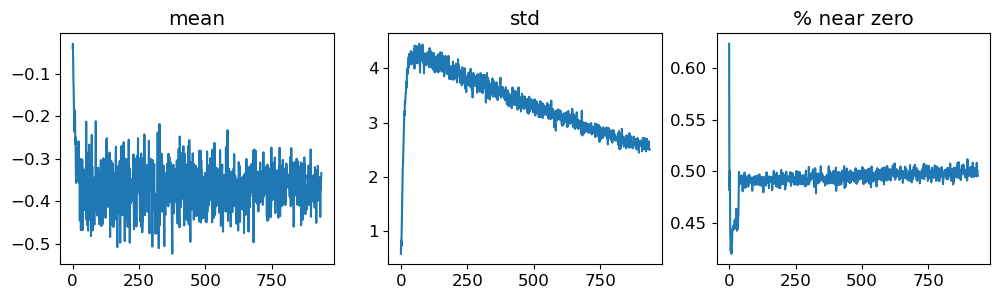

In [53]:
# Plot activation stats for the FIRST layer (index 0)
# Shows mean, std, and % of near-zero activations over training batches
learn.activation_stats.plot_layer_stats(0)

The plot shows three metrics across training batches (each batch = one forward pass on a chunk of images):

**Mean (left)** — The average activation value at this layer. It's hovering slightly below zero and a bit noisy, but roughly stable. Not ideal, but not catastrophic — the first layer is receiving raw pixel data directly, so it has a decent signal to work with.

**Std (middle)** — How spread out the activation values are. It's bouncing around but staying in a reasonable range. The layer is producing a variety of output values, which means it can still distinguish between different input patches.

**% near zero (right)** — What fraction of activations are effectively dead (near zero after ReLU). It's around 50% — not great, but the layer is still passing some signal through.

The first layer looks okay. But problems compound as you go deeper — each layer feeds into the next, so small issues amplify. Let's check the penultimate layer (second-to-last, right before the final prediction):

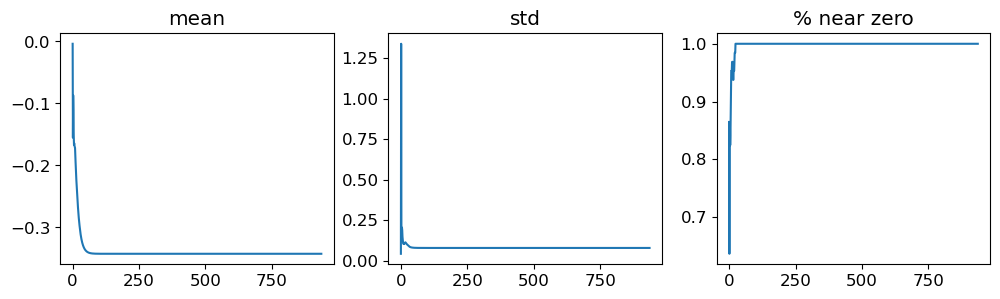

In [54]:
# Plot activation stats for the PENULTIMATE layer (-2 = second to last)
# Problems compound deeper in the network — this layer usually shows the worst issues
learn.activation_stats.plot_layer_stats(-2)

The x-axis on all three charts is **training batches** — each tick is one batch of images passed through the network.

**Mean (left)** — The average activation value at this layer. It's around -3 to -4 and swinging wildly. Bad in two ways: it's negative (meaning most values before ReLU are negative, so ReLU kills them), and it's erratic (the layer isn't settling into stable behavior). A healthy mean would be near zero and smooth.

**Std (middle)** — How spread out the activation values are. It starts high (~4) and gradually drops, meaning the activations are collapsing — the range of values is shrinking over time. The layer is losing its ability to distinguish between different inputs. A healthy std would be stable around 1-2.

**% near zero (right)** — The killer. ~95-100% of activations at this layer are near zero. After ReLU zeros out the negatives, almost nothing is left. This layer is essentially dead — it's outputting zeros for nearly every input, so the final prediction layer has almost nothing to work with.

The story these three tell together: the mean is deeply negative → ReLU kills most values → nearly everything is zero → the network is guessing randomly. That's why we got ~10% accuracy (1 out of 10 classes = pure chance).

### Increase Batch Size

Larger batches give smoother gradient estimates — each gradient is averaged over more samples, so individual noisy examples have less influence on the update step. The tradeoff: fewer batches per epoch means fewer weight updates, so the model gets less opportunity to learn per pass through the data. Let's try batch size 512 instead of 64:

In [55]:
# Experiment 1: increase batch size from 64 → 512
# Larger batches = smoother gradient estimates = more stable training
dls = get_dls(512)

In [56]:
# Retrain with larger batch size
learn = fit()

epoch,train_loss,valid_loss,accuracy,time
0,2.319333,2.302242,0.113500,00:01


~90% accuracy — a big jump from 10%, but still poor for MNIST (a simple MLP can hit 97%+). Let's check if the underlying problem is fixed:

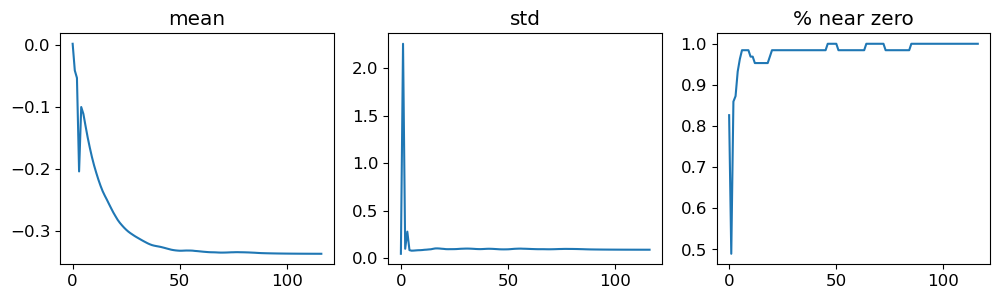

In [57]:
# Check penultimate layer — still lots of near-zero activations
learn.activation_stats.plot_layer_stats(-2)

Compare this to the first attempt: the mean is more stable and the std isn't collapsing as fast — the smoother gradients from the larger batch are helping the weight updates. But look at **% near zero** — it's still very high, hovering around 90%+. Most neurons at this layer are still dead.

The larger batch stabilized the gradients (smoother weight updates), but didn't fix the root cause: the activations themselves — the actual values flowing between layers — are drifting toward zero as they pass through the network. We need something that directly addresses this activation distribution problem.

### 1cycle Training

The problem: starting with a high learning rate when weights are still random can destabilize training immediately — the updates are too aggressive for a network that hasn't learned anything yet. But we also don't want a low learning rate the whole time — that's slow. The **1cycle policy** (a learning rate schedule, not an optimizer) solves this: start with a low lr (safe warm-up while weights are random), gradually ramp up to a high lr (fast learning once the network has found a reasonable direction), then decay back down (fine-tune the details at the end).

In [58]:
from fastai.learner import Learner
from fastai.metrics import accuracy
from fastai.callback.hook import ActivationStats

# Experiment 2: use fit_one_cycle instead of fit
# 1cycle policy: lr starts low, ramps up to max, then decays
# This avoids destabilizing the model early when weights are random
def fit(epochs=1, lr=0.06):
    learn = Learner(dls, simple_cnn(), loss_func=F.cross_entropy,
                    metrics=accuracy, cbs=ActivationStats(with_hist=True))
    learn.fit_one_cycle(epochs, lr)
    return learn

In [59]:
# Train with 1cycle — should see better accuracy than plain fit()
learn = fit()

epoch,train_loss,valid_loss,accuracy,time
0,0.198419,0.075171,0.974200,00:02


97.7% — a huge improvement! 1cycle training made the difference. We can visualize the learning rate schedule to see the warm-up and decay:

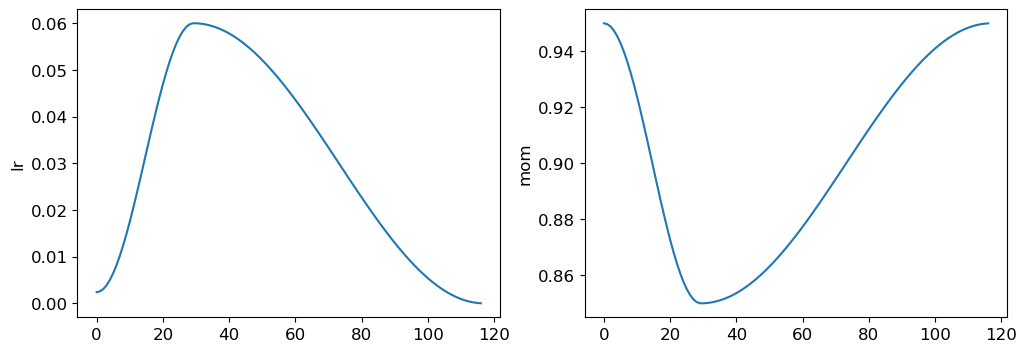

In [60]:
# Visualize the learning rate schedule: warmup then cosine annealing
learn.recorder.plot_sched()

fastai's implementation uses cosine annealing for the decay phase — a smooth curve instead of linear decay — which tends to work slightly better in practice. You can see the warm-up and decay shape in the plot above.

Let's check if the activations improved:

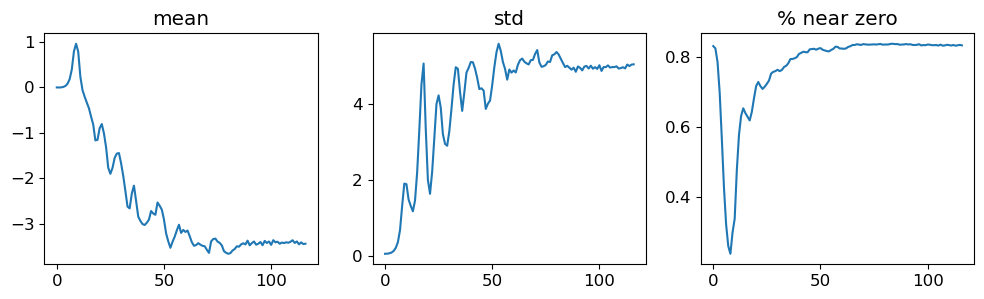

In [61]:
# Penultimate layer stats with 1cycle — should be more stable
learn.activation_stats.plot_layer_stats(-2)

Better — the mean is more stable than before, and the std isn't collapsing. The 1cycle schedule clearly helped the learning dynamics. But **% near zero** is still stubbornly high. Despite the accuracy jump to 97.7%, the activations at this layer are still mostly dead. The network is getting by because a few surviving neurons carry enough signal — but it's fragile. We need something that fixes the activations directly.

### Batch Normalization

Let's recap the problem. We've tried two fixes — larger batches and 1cycle — and both helped accuracy, but the `plot_layer_stats` keep showing the same thing: most activations at the deeper layers are near zero. The network learns *despite* this, not *because* of healthy internals.

Why does this happen? Each layer takes the previous layer's output (activations) and transforms it. If one layer's output drifts slightly toward zero, the next layer receives smaller inputs, which makes *its* output drift further toward zero. This compounds — by layer 5, the signal from the original image is gone. This is called **activation drift**.

**Batch normalization** fixes this directly. After each conv layer, it normalizes the activations to have zero mean and unit variance — using the mean and std of the current training batch. Think of it as a reset button: no matter how much the previous layer's output drifted, batchnorm pulls it back to a healthy distribution before passing it on.

The simulation below shows this concept in isolation — no ReLU, just the drift and the reset. This is how most textbooks illustrate batchnorm, because it shows the core idea clearly:

Three things to notice:

**Top row (no BN)**: Activations narrow and die off with depth — the distributions collapse and % dead increases. This is the activation drift we've been diagnosing.

**Middle row (ReLU→BN, this notebook)**: Distributions stay alive but look skewed. BN is normalizing a post-ReLU distribution (all ≥ 0), so it can re-center but not remove the skew. Still, the signal survives through all layers.

**Bottom row (BN→ReLU, modern default)**: The ~50% dead neurons look alarming but are actually **expected and healthy**. BN produces a symmetric distribution centered at zero, then ReLU clips the negative half — that's exactly 50%. This is ReLU's normal sparsity property, not pathological dying neurons. The non-zero half forms a clean half-normal shape that stays consistent across layers. In practice, BN's learnable gamma and beta can shift the center, so the network controls what fraction gets clipped.

Both BN orderings work well — empirical comparisons show minimal accuracy difference. This notebook keeps ReLU→BN to follow the fastai book. Conv→BN→ReLU is the more standard ordering (original BN paper, PyTorch's ResNet) and a good default for building from scratch.

Now, there's a catch with batchnorm: if we force every layer's output to be exactly zero mean and unit variance, we might be removing information the network needs. Maybe some activations *should* be large to make a confident prediction. So batchnorm also learns two parameters per channel: **gamma** (scale) and **beta** (shift). After normalizing to get `y`, it computes `gamma * y + beta`. This lets the network adjust the distribution if it needs to — but it starts from a healthy baseline instead of wherever the drift landed.

One detail: during training, batchnorm uses the current batch's mean and std. During validation/inference there's no batch to compute statistics from, so it uses a running average that was tracked during training.

Let's add a batchnorm layer to `conv`:

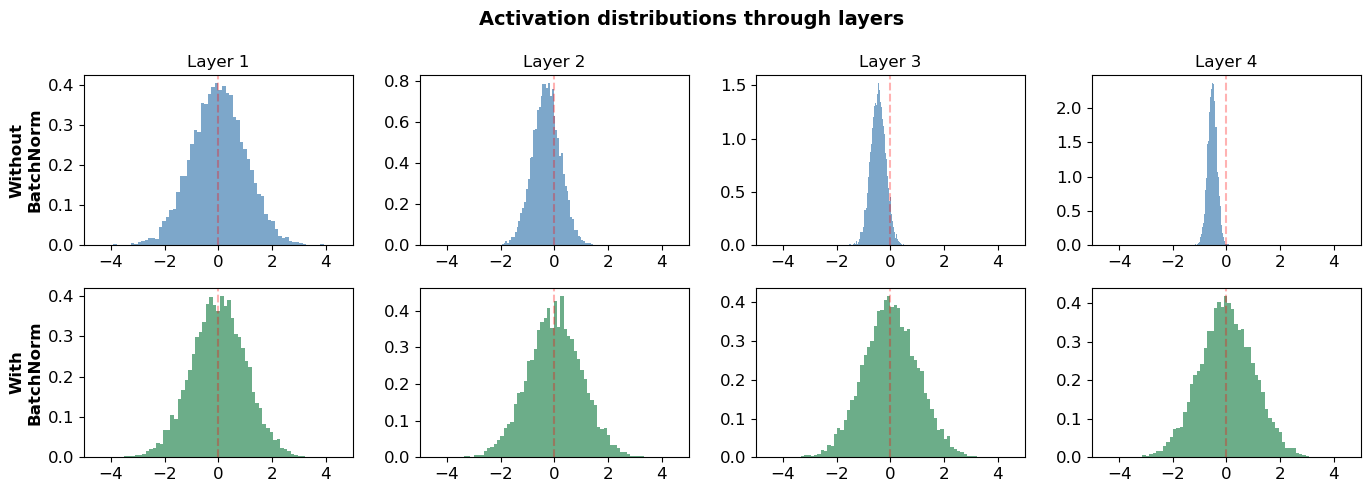

In [62]:
# Simulating activation drift: what happens to values as they pass through layers

np.random.seed(42)

# Without batchnorm: activations drift and collapse
no_bn_layers = []
values = np.random.randn(10000)
for _ in range(4):
    no_bn_layers.append(values.copy())
    values = values * 0.5 - 0.3 + np.random.randn(10000) * 0.1  # shrink + shift

# With batchnorm: same drift, but reset after each layer
bn_layers = []
values = np.random.randn(10000)
for _ in range(4):
    bn_layers.append(values.copy())
    values = values * 0.5 - 0.3 + np.random.randn(10000) * 0.1  # same drift
    values = (values - values.mean()) / (values.std() + 1e-5)    # batchnorm reset

plot_activation_drift([
    {'values_per_layer': no_bn_layers, 'label': 'Without\nBatchNorm', 'color': 'steelblue'},
    {'values_per_layer': bn_layers,    'label': 'With\nBatchNorm',    'color': 'seagreen'},
])

The simulation shows the pure concept: without batchnorm, the distribution collapses into a narrow spike. With batchnorm, it stays spread out at every layer. But our real CNN also applies **ReLU** after each convolution, which changes the picture — ReLU zeros out all negative values, so the output of each layer is always ≥ 0.

Let's see what real MNIST activations look like. We'll pass actual images through two untrained models (random weights) — one without batchnorm and one with (using our notebook's Conv → ReLU → BN ordering):

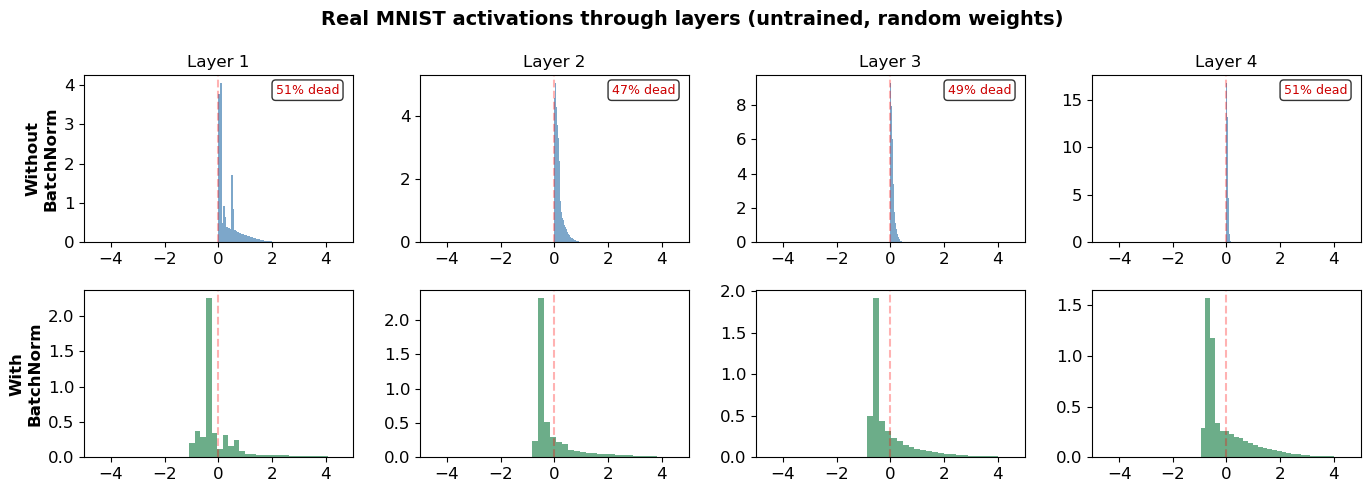

In [63]:
# Pass real MNIST images through two untrained models and compare activations

x, _ = dls.one_batch()  # grab a real batch of MNIST digits
device = x.device         # match the device (CPU or GPU)

def get_layer_activations(model, x):
    """Forward pass through model, collect the output of each conv block."""
    activations = []
    hooks = []
    for layer in model:
        if isinstance(layer, nn.Sequential):  # each conv() block is an nn.Sequential
            def hook(module, input, output, store=activations):
                store.append(output.detach().cpu().flatten().numpy())
            hooks.append(layer.register_forward_hook(hook))
    with torch.no_grad():
        model(x)
    for h in hooks:
        h.remove()
    return activations

# Model WITHOUT batchnorm (uses current conv definition)
model_no_bn = simple_cnn().to(device)

# Model WITH batchnorm (define inline so we don't overwrite conv yet)
def conv_bn(in_channels, out_channels, kernel_size=3, activation=True):
    layers = [nn.Conv2d(in_channels=in_channels, out_channels=out_channels,
                        kernel_size=kernel_size, stride=2, padding=kernel_size // 2)]
    if activation:
        layers.append(nn.ReLU())
    layers.append(nn.BatchNorm2d(out_channels))
    return nn.Sequential(*layers)

from fastai.layers import sequential, Flatten
model_bn = sequential(
    conv_bn(1, 8, 5), conv_bn(8, 16), conv_bn(16, 32),
    conv_bn(32, 64), conv_bn(64, 10, activation=False), Flatten()
).to(device)

# Collect activations from each conv block
acts_no_bn = get_layer_activations(model_no_bn, x)
acts_bn = get_layer_activations(model_bn, x)

plot_activation_drift([
    {'values_per_layer': acts_no_bn, 'label': 'Without\nBatchNorm', 'color': 'steelblue'},
    {'values_per_layer': acts_bn,    'label': 'With\nBatchNorm',    'color': 'seagreen'},
], title='Real MNIST activations through layers (untrained, random weights)')

The top row shows activations without batchnorm: the distributions narrow with depth and more neurons die (the "% dead" labels). This matches the `plot_layer_stats` we saw earlier. The bottom row (with BN) keeps activations alive — the distributions stay spread out.

But notice the bottom row looks skewed, not the clean bell curve from our simulation. That's because of **layer ordering**. Our `conv` helper applies **Conv → ReLU → BN**. ReLU kills all negatives first, so BN receives a lopsided (all ≥ 0) input. It re-centers it around zero (which is why some values go negative), but the shape stays skewed.

The more common ordering in modern architectures (PyTorch's ResNet, the original BN paper) is **Conv → BN → ReLU**. Here, BN normalizes the full symmetric output from Conv into a clean bell curve, and *then* ReLU clips the negative half. Let's compare all three:

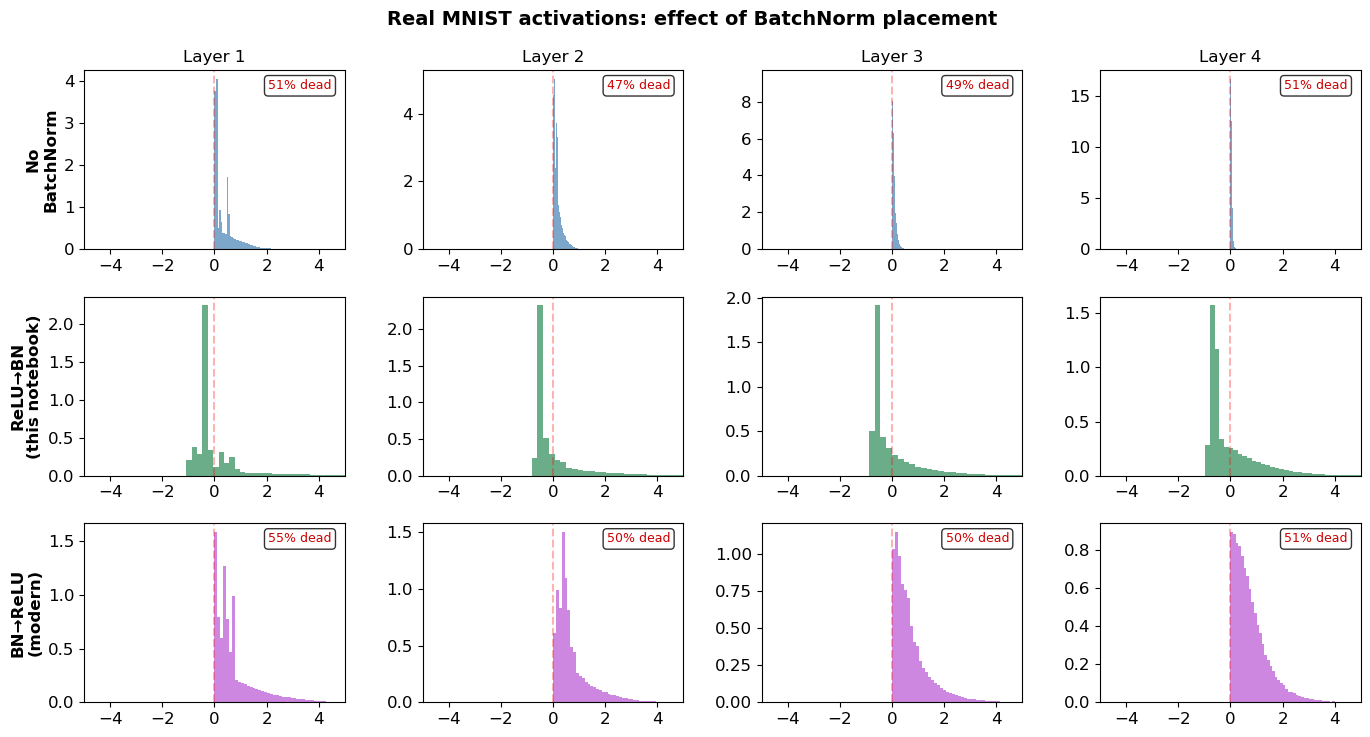

In [64]:
# Same comparison but with BN BEFORE ReLU: Conv → BN → ReLU
def conv_bn_relu(in_channels, out_channels, kernel_size=3, activation=True):
    layers = [nn.Conv2d(in_channels=in_channels, out_channels=out_channels,
                        kernel_size=kernel_size, stride=2, padding=kernel_size // 2)]
    if activation:
        layers.append(nn.BatchNorm2d(out_channels))  # BN first
        layers.append(nn.ReLU())                      # then ReLU
    return nn.Sequential(*layers)

model_bn_relu = sequential(
    conv_bn_relu(1, 8, 5), conv_bn_relu(8, 16), conv_bn_relu(16, 32),
    conv_bn_relu(32, 64), conv_bn_relu(64, 10, activation=False), Flatten()
).to(device)

acts_bn_relu = get_layer_activations(model_bn_relu, x)

plot_activation_drift([
    {'values_per_layer': acts_no_bn,   'label': 'No\nBatchNorm',    'color': 'steelblue'},
    {'values_per_layer': acts_bn,      'label': 'ReLU→BN\n(this notebook)', 'color': 'seagreen'},
    {'values_per_layer': acts_bn_relu, 'label': 'BN→ReLU\n(modern)', 'color': 'mediumorchid'},
], title='Real MNIST activations: effect of BatchNorm placement')

In [65]:
# Experiment 3: add BatchNorm2d after each conv layer
# BatchNorm normalizes activations (zero mean, unit variance) within each batch
# This prevents the activation distribution from drifting during training
def conv(in_channels, out_channels, kernel_size=3, activation=True):
    layers = [nn.Conv2d(
        in_channels=in_channels,
        out_channels=out_channels,
        kernel_size=kernel_size,
        stride=2,
        padding=kernel_size // 2
    )]
    if activation:
        layers.append(nn.ReLU())
    layers.append(nn.BatchNorm2d(out_channels))  # normalize per-channel activations
    return nn.Sequential(*layers)

and fit our model:

In [66]:
# Train with batchnorm — should see a big improvement in accuracy
learn = fit()

epoch,train_loss,valid_loss,accuracy,time
0,0.134344,0.055182,0.985800,00:02


98.6% in just 1 epoch — a massive improvement. But we've been burned before by good accuracy with bad activations (remember 1cycle got 97.7% but neurons were still mostly dead). Let's check with `plot_layer_stats`:

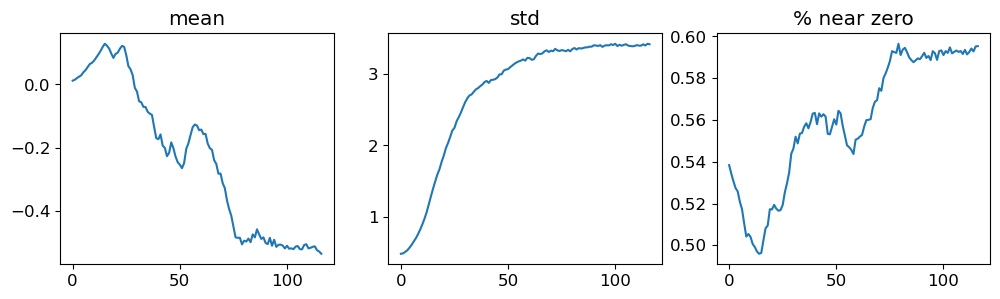

In [67]:
# Penultimate layer stats with batchnorm
# -4 because batchnorm adds extra layers to the model, shifting indices
learn.activation_stats.plot_layer_stats(-4)

Compare this to our earlier penultimate layer plots:

- **Mean** — stable and near zero (was erratic and deeply negative before)
- **Std** — holding steady (was collapsing toward zero)
- **% near zero** — dramatically lower (was 95%+, now the neurons are actually alive)

The activations are healthy from the very first batch. Batchnorm fixed the root cause we've been chasing this whole section — activation drift. It's so effective that nearly all modern neural networks use it or a close variant (LayerNorm, GroupNorm).

And because the network is now stable, we can push to a higher learning rate without things blowing up. Let's train for 5 epochs at lr=0.1:

In [68]:
# Now train for 5 epochs with a higher learning rate
# BatchNorm stabilizes training enough that we can push lr to 0.1
learn = fit(5, lr=0.1)

epoch,train_loss,valid_loss,accuracy,time
0,0.186272,0.102059,0.968300,00:03
1,0.079976,0.087548,0.973300,00:02
2,0.051664,0.047763,0.985200,00:03
3,0.032504,0.032612,0.989600,00:02
4,0.016953,0.026888,0.991300,00:03


At this point, I think it's fair to say we know how to recognize digits! It's time to move on to something harder...

## Conclusions

We've seen that convolutions are just a type of matrix multiplication, with two constraints on the weight matrix: some elements are always zero, and some elements are tied (forced to always have the same value). In  we saw the eight requirements from the 1986 book *Parallel Distributed Processing*; one of them was "A pattern of connectivity among units." That's exactly what these constraints do: they enforce a certain pattern of connectivity.

These constraints allow us to use far fewer parameters in our model, without sacrificing the ability to represent complex visual features. That means we can train deeper models faster, with less overfitting. Although the universal approximation theorem shows that it should be *possible* to represent anything in a fully connected network in one hidden layer, we've seen now that in *practice* we can train much better models by being thoughtful about network architecture.

Convolutions are by far the most common pattern of connectivity we see in neural nets (along with regular linear layers, which we refer to as *fully connected*), but it's likely that many more will be discovered.

We've also seen how to interpret the activations of layers in the network to see whether training is going well or not, and how batchnorm helps regularize the training and makes it smoother. In the next chapter, we will use both of those layers to build the most popular architecture in computer vision: a residual network.

## Questionnaire

**Convolutions and kernels**

1. What is a convolution? Describe the operation step by step.
1. What is the difference between a kernel and a feature map?
1. Write out a 3×3 kernel matrix that detects top edges. What would a feature map from this kernel look like on an image with a horizontal line?
1. What is the value of any kernel applied to a 3×3 matrix of zeros? Why?
1. What is "padding"? What does `padding=1` do with a 3×3 kernel?
1. What is "stride"? Why does stride 2 replace max pooling in modern architectures?
1. What are the shapes of the `input` and `weight` parameters to PyTorch's `F.conv2d`?
1. What does "NCHW" mean?

**Channels and architecture**

1. What is a "channel"? How does the meaning change between the input image and later layers?
1. The word "feature" means different things in tabular ML vs CNNs. Explain both meanings.
1. A conv layer receives 4 input channels. What is the shape of a single kernel in that layer? How many numbers does it output per spatial position?
1. Why do we double the number of filters after each stride-2 conv?
1. Why does `simple_cnn` use a larger kernel (5×5) in the first layer?
1. What is a "receptive field"? What is the receptive field size after two stride-2 convolutions with 3×3 kernels?
1. What does `Flatten` do in the CNN? Where does it go and why?
1. How is a color (RGB) image represented as a tensor? How does a convolution work on it — what shape is the kernel?

**Training stability and diagnostics**

1. What is the difference between *weights* and *activations*?
1. What are the three statistics plotted by `plot_layer_stats`? What does the x-axis represent?
1. Why are activations near zero problematic? What causes this in deeper layers?
1. What is "activation drift" and why does it compound through layers?
1. What are the upsides and downsides of training with a larger batch size?
1. Why should we avoid using a high learning rate at the start of training?
1. What is 1cycle training? Describe the three phases and why each matters. Is it an optimizer or a scheduler?
1. What trainable parameters does a batch normalization layer contain? Why are they needed?
1. What statistics does batch normalization use during training? How about during validation/inference?
1. Why does batch normalization allow us to use a higher learning rate?

### Further Research

1. What features other than edge detectors have been used in computer vision (especially before deep learning became popular)?
1. There are other normalization layers available in PyTorch (LayerNorm, GroupNorm, InstanceNorm). Try them out and see what works best. When would you use each?
1. Try moving the activation function (ReLU) after the batch normalization layer in `conv`. Does it make a difference? Research what order is recommended and why.
1. Run *conv-example.xlsx* yourself and experiment with *trace precedents* to see how receptive fields grow through layers.

<div style="text-align: center; color: #888; font-size: 0.85em; margin-top: 40px; padding-top: 10px; border-top: 1px solid #ddd;">
© 2025 Utvecklarakademin UA Aktiebolag. All rights reserved.<br>
This material is proprietary and may not be reproduced, distributed, or shared without written permission.
</div>